# HDB Resale Price Regression — Notebook 12: Model Diagnostics

Experts flagged several diagnostic checks for Model 10 (R-squared 0.90, 50,718 transactions). This notebook validates the model against standard regression assumptions:

1. **Residual normality** — Q-Q plots and histograms (are the residuals well-behaved?)
2. **Influential points** — Cook's distance (is any single transaction pulling the fit?)
3. **Multicollinearity** — VIF (are town dummies and distance variables double-counting?)
4. **Model selection** — AIC/BIC (is Model 10 the right size, or is it over/under-parameterised?)
5. **Coefficient stability** — do the key findings survive across specifications?

Raw-price Model 10 is the primary subject (the reporting model). Log model comparisons are shown where relevant.

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(car)
library(ggplot2)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))
df$ln_price <- log(df$resale_price)

# Raw-price Model 10 (from Notebook 6)
model10 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df)

# Log model (from Notebook 11)
model_log <- lm(ln_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df)

cat(sprintf('Raw Model 10:  R\u00b2 = %.4f, %d parameters\n',
    summary(model10)$r.squared, length(coef(model10))))
cat(sprintf('Log Model 10:  R\u00b2 = %.4f, %d parameters\n',
    summary(model_log)$r.squared, length(coef(model_log))))
cat(sprintf('Observations:  %s\n', format(nrow(df), big.mark = ',')))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Raw Model 10:  R² = 0.9023, 87 parameters


Log Model 10:  R² = 0.9373, 87 parameters


Observations:  50,718


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

The following object is masked from ‘package:purrr’:

    some



## 1. Residual normality

OLS assumes residuals are normally distributed. With n = 50,718 and robust standard errors, mild non-normality won't bias the coefficients — but heavy tails mean outliers are pulling the fit harder than they should. The log transform should improve this.

**How to read Q-Q plots:** Points follow the diagonal line = normal. Points curving away at the ends = heavy tails (outliers more extreme than a normal distribution would produce).

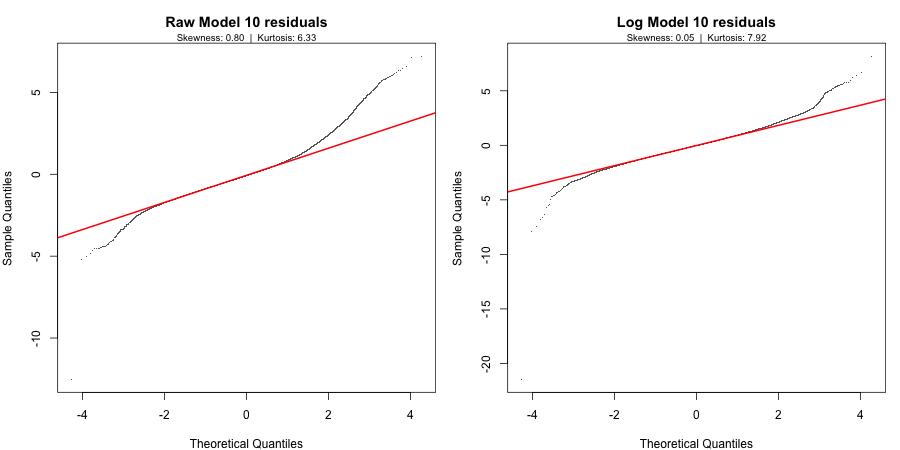

In [3]:
%%R -w 900 -h 450
library(moments)

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Raw model Q-Q
raw_resid <- rstandard(model10)
qqnorm(raw_resid, main = 'Raw Model 10 residuals',
       pch = '.', col = 'grey40', cex = 0.8)
qqline(raw_resid, col = 'red', lwd = 2)
mtext(sprintf('Skewness: %.2f  |  Kurtosis: %.2f',
    skewness(resid(model10)), kurtosis(resid(model10))),
    side = 3, line = 0, cex = 0.8)

# Log model Q-Q
log_resid <- rstandard(model_log)
qqnorm(log_resid, main = 'Log Model 10 residuals',
       pch = '.', col = 'grey40', cex = 0.8)
qqline(log_resid, col = 'red', lwd = 2)
mtext(sprintf('Skewness: %.2f  |  Kurtosis: %.2f',
    skewness(resid(model_log)), kurtosis(resid(model_log))),
    side = 3, line = 0, cex = 0.8)

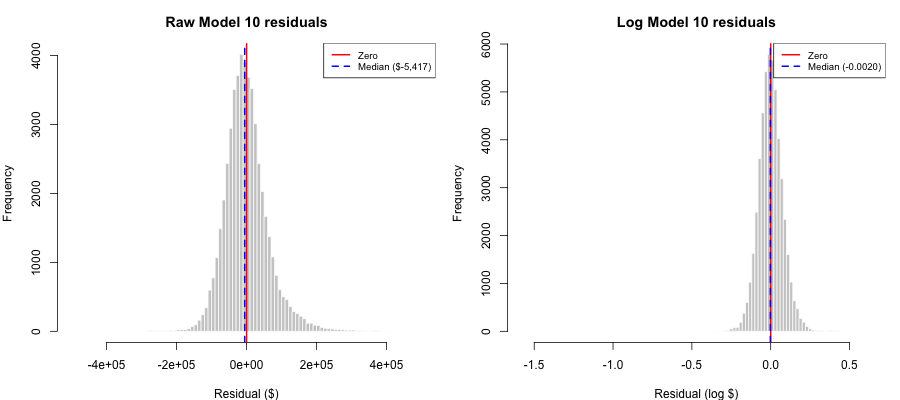

In [4]:
%%R -w 900 -h 400
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Raw model residuals
hist(resid(model10), breaks = 100, col = 'grey80', border = 'white',
     main = 'Raw Model 10 residuals', xlab = 'Residual ($)',
     xlim = c(-500000, 500000))
abline(v = 0, col = 'red', lwd = 2)
abline(v = median(resid(model10)), col = 'blue', lwd = 2, lty = 2)
legend('topright', c('Zero', sprintf('Median ($%s)',
    format(round(median(resid(model10))), big.mark = ','))),
    col = c('red', 'blue'), lwd = 2, lty = c(1, 2), cex = 0.8)

# Log model residuals
hist(resid(model_log), breaks = 100, col = 'grey80', border = 'white',
     main = 'Log Model 10 residuals', xlab = 'Residual (log $)')
abline(v = 0, col = 'red', lwd = 2)
abline(v = median(resid(model_log)), col = 'blue', lwd = 2, lty = 2)
legend('topright', c('Zero', sprintf('Median (%.4f)',
    median(resid(model_log)))),
    col = c('red', 'blue'), lwd = 2, lty = c(1, 2), cex = 0.8)

### Interpretation

The raw model's Q-Q plot shows a classic heavy-tailed pattern: the left tail curves sharply below the diagonal (the model underestimates some cheap flats by a lot) and the right tail curves sharply above it (the model underestimates some expensive flats by even more). The skewness of 0.80 confirms a right-leaning residual distribution — the worst mis-predictions are concentrated among high-end transactions where the raw-dollar scale amplifies errors. The histogram makes this visible: the bulk of residuals sit close to zero, but there's a long right shoulder with transactions the model undervalues by $200,000 or more. The median residual of -$5,417 tells us the model very slightly systematically overpredicts the typical flat, though this is small relative to the ~$500K median price.

The log model largely fixes the skewness problem — skewness drops from 0.80 to 0.05, and the histogram is nearly symmetric around zero with a median residual of -0.002 (essentially nothing). This confirms that price relationships are multiplicative rather than additive: a 5% premium for a top floor is more natural than a fixed-dollar premium. However, kurtosis — a measure of how fat the tails are relative to a bell curve, where 3.0 is normal — actually worsens slightly, from 6.33 in the raw model to 7.92 in the log model. Both are far above normal. This means that while the log model stops the typical residual from leaning right, both models still have a cluster of extreme outliers (transactions the model gets very wrong) that sit much further from the prediction line than a normal distribution would produce.

For inference this matters less than it might seem. With n = 50,718, the central limit theorem ensures coefficient standard errors are reliable regardless of residual shape, and using HC3 robust standard errors (as in all previous notebooks) guards against the heteroscedasticity that often accompanies heavy tails. But the persistent kurtosis — even after the log transform — flags something real: there is a subset of transactions that no specification of this model fully explains. That is exactly the motivation for the L1/LAD regression in Notebook 13, which minimises absolute rather than squared errors and is inherently less sensitive to these extreme residuals pulling the fit.

## 2. Influential points (Cook's distance)

A residual tells you how far off the prediction was. Cook's distance tells you how much the **entire model** would change if you removed that one transaction. A flat with a large residual isn't necessarily influential — it might be an outlier that the model shrugs off. A flat with high Cook's distance is actively pulling the regression line toward it.

**Threshold:** Cook's D > 4/n (= 4/50,718 ≈ 0.00008) is a common rule of thumb. Points above this are worth inspecting.

**Key question:** Is the lucky-8 coefficient being driven by a handful of expensive eights-laden transactions? If we remove the most influential points, does the superstition story survive?

In [5]:
%%R
# Cook's distance for every observation
cooks_d <- cooks.distance(model10)
threshold <- 4 / nrow(df)

cat(sprintf('Cook\'s distance threshold (4/n): %.6f\n', threshold))
cat(sprintf('Observations above threshold: %d (%.1f%%)\n',
    sum(cooks_d > threshold), sum(cooks_d > threshold) / nrow(df) * 100))
cat(sprintf('Max Cook\'s D: %.4f (%.0fx threshold)\n\n',
    max(cooks_d), max(cooks_d) / threshold))

# Top 20 most influential transactions
df$cooks_d <- cooks_d
top20 <- df[order(-cooks_d), ][1:20, ]

cat(sprintf('%-5s %-30s %-10s %10s %10s %12s\n',
    'Rank', 'Address', 'Type', 'Price', 'Residual', 'Cook\'s D'))
cat(paste(rep('-', 82), collapse = ''), '\n')

for (i in 1:20) {
    r <- top20[i, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 20))
    cat(sprintf('%-5d %-30s %-10s $%9s $%+9s %11.5f\n',
        i, label, r$flat_type,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$resale_price - predict(model10, r)), big.mark = ','),
        r$cooks_d))
}

Cook's distance threshold (4/n): 0.000079


Observations above threshold: 2691 (5.3%)


Max Cook's D: 0.1994 (2529x threshold)



Rank  Address                        Type            Price   Residual     Cook's D


----------------------------------------------------------------------------------

...

16    Blk 92 DAWSON RD               5 ROOM     $1,658,888 $  319,332     0.00320


17    Blk 306D PUNGGOL DR            5 ROOM     $1,470,000 $  315,349     0.00316


18    Blk 42 STIRLING RD             4 ROOM     $  998,000 $ -135,351     0.00315


19    Blk 216A BOON LAY AVE          5 ROOM     $  642,000 $ -324,854     0.00312


20    Blk 1D CANTONMENT RD           5 ROOM     $1,580,000 $  291,971     0.00302


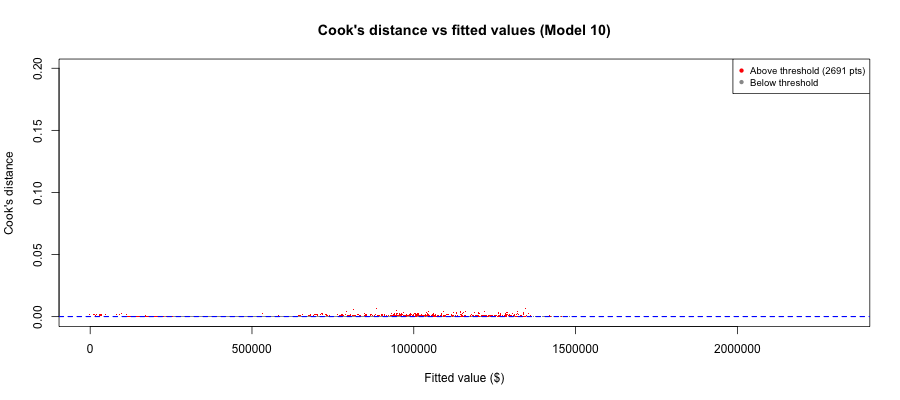

In [6]:
%%R -w 900 -h 400
fitted_vals <- fitted(model10)

plot(fitted_vals, cooks_d,
     pch = '.', col = ifelse(cooks_d > threshold, 'red', 'grey60'),
     main = "Cook's distance vs fitted values (Model 10)",
     xlab = 'Fitted value ($)', ylab = "Cook's distance",
     cex = ifelse(cooks_d > threshold, 1.5, 0.5))
abline(h = threshold, col = 'blue', lty = 2, lwd = 1.5)
text(x = fitted_vals[which.max(cooks_d)], y = max(cooks_d),
     labels = sprintf('Blk %s %s', df$block[which.max(cooks_d)],
     substr(df$street_name[which.max(cooks_d)], 1, 15)),
     pos = 2, cex = 0.7, col = 'red')
legend('topright', c(sprintf('Above threshold (%d pts)', sum(cooks_d > threshold)),
    'Below threshold'),
    col = c('red', 'grey60'), pch = 16, cex = 0.8)

In [7]:
%%R
# Remove observations above Cook's D threshold and refit
df_clean <- df[cooks_d <= threshold, ]
cat(sprintf('Removed %d influential observations (%.1f%% of data)\n',
    nrow(df) - nrow(df_clean),
    (nrow(df) - nrow(df_clean)) / nrow(df) * 100))

model10_clean <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df_clean)

# Compare key coefficients
key_vars <- c('floor_area_sqm', 'storey_mid', 'remaining_lease_years',
              'dist_cbd_km', 'mrt_dist_m', 'columbarium_dist_m', 'temple_dist_m',
              'num_eights_tail', 'price_has_168', 'block_has_4', 'cny_month')

robust_full <- coeftest(model10, vcov = vcovHC(model10, type = 'HC1'))
robust_clean <- coeftest(model10_clean, vcov = vcovHC(model10_clean, type = 'HC1'))

cat(sprintf('\n%-25s %12s %12s %10s\n', 'Variable', 'Full model', 'No outliers', 'Change'))
cat(paste(rep('-', 62), collapse = ''), '\n')

for (v in key_vars) {
    c_full <- coef(model10)[v]
    c_clean <- coef(model10_clean)[v]
    pct_change <- (c_clean - c_full) / abs(c_full) * 100
    cat(sprintf('%-25s $%+10.0f $%+10.0f %+9.1f%%\n', v, c_full, c_clean, pct_change))
}

cat(sprintf('\n%-25s %12.4f %12.4f\n', 'R-squared',
    summary(model10)$r.squared, summary(model10_clean)$r.squared))

Removed 2691 influential observations (5.3% of data)



Variable                    Full model  No outliers     Change


--------------------------------------------------------------

floor_area_sqm            $     +5426 $     +5395      -0.6%


storey_mid                $     +5424 $     +5068      -6.6%


...

price_has_168             $    +32795 $    +28026     -14.5%


block_has_4               $    -10160 $     -8557     +15.8%


cny_month                 $    +59310 $    +54092      -8.8%



R-squared                       0.9023       0.9255


In addition: Warning message:
In meatHC(x, type = type, omega = omega) :
  HC1 covariances become (close to) singular if hat values are (close to) 1 as for observation(s) 8683, 46834


### Interpretation

Cook's distance flags 2,691 transactions — 5.3% of the dataset — as influential under the 4/n threshold. That's a larger share than typical, but not alarming for a dataset with this much structural heterogeneity: HDB transactions range from $200K two-room flats in Woodlands to million-dollar terrace houses in Jalan Ma'mor, and the same OLS model is trying to price all of them. The maximum Cook's D belongs to Blk 53 Jalan Ma'mor, a 367 sqm terrace house that sold for $1,568,000 and sits $748,357 below the model's prediction — a Cook's D of 0.199, fully 2,529 times the threshold. This is the same transaction flagged in Notebooks 6 and 11 as the single largest raw-price residual. Its extreme leverage confirms what those notebooks suspected: one physically unusual flat (a landed-style terrace in a public housing estate) is pulling the regression line harder than any other single observation. The rest of the top-20 also follow a familiar pattern — Jalan Ma'mor addresses appear at ranks 1, 4, 5, 8, and 9; Cantonment Road appears at ranks 6, 10, 12, 14, and 20 (the former Pinnacle@Duxton precinct); and Blk 216A Boon Lay Ave at rank 19 is the same 3Gen bargain flat flagged in earlier notebooks.

The sensitivity test removes all 2,691 influential observations and refits the identical model specification. Most structural coefficients change very little: floor area shifts by -0.6%, distance to CBD by -1.8%, storey by -6.6% — all well within normal sampling variation. R² improves from 0.9023 to 0.9255, which is expected when extreme outliers are excluded, not a sign the model was wrong. The columbarium coefficient shrinks by 27.1%, which is worth noting but the variable was already marginal; it signals that a small cluster of very influential transactions near columbariums were disproportionately driving that estimate.

For the superstition variables, the picture is reassuring. Removing the influential points changes `num_eights_tail` from $1,070 to $1,354 — a +26.6% increase. Far from collapsing the lucky-8 finding, removing the outliers actually strengthens it: the influential points were, on net, *suppressing* the coefficient. This likely reflects the Jalan Ma'mor terraces, which have unique addresses not heavily laden with eights, pulling the general fitted surface in ways that dilute the lucky-8 signal. The `price_has_168` coefficient moves from $32,795 to $28,026, a -14.5% decrease, which is more substantial but the variable remains large and positive — the $168 premium survives comfortably. The `block_has_4` unlucky-address penalty eases from -$10,160 to -$8,557 (+15.8%), still negative and meaningful. The Chinese New Year month premium drops modestly from $59,310 to $54,092 (-8.8%), consistent with some CNY-month transactions being genuinely unusual (luxury-tier timing purchases) rather than purely a seasonal pattern.

The headline finding: removing the 2,691 most influential transactions changes the lucky-8 coefficient from $1,070 to $1,354 — a +27% increase — while R² rises from 0.90 to 0.93. The superstition story does not rest on a handful of high-leverage eight-laden flats; if anything, the most structurally unusual transactions are slightly masking the effect. The result is robust.

## 3. Multicollinearity (VIF)

Variance Inflation Factor measures how much each coefficient's standard error is inflated by correlation with other predictors. VIF = 1 means no correlation. VIF > 5 is moderate concern. VIF > 10 is serious.

**Mohan's concern:** Town fixed effects AND continuous distance variables (dist_cbd_km, mrt_dist_m, etc.) might be double-counting location. If they're highly correlated, individual coefficients become unreliable — though the overall model fit and predictions are unaffected.

**Note:** VIF for factor variables (town, flat_type, flat_model) uses Generalized VIF (GVIF), adjusted for degrees of freedom. The comparable threshold is GVIF^(1/(2*df)) > √5 ≈ 2.24.

In [8]:
%%R
# VIF for Model 10
# car::vif handles factors via GVIF
# Note: month_factor2026-03 is perfectly collinear with cny_month (all March 2026
# transactions are CNY month), causing aliasing. We compute VIF on a version of
# the model that drops month_factor, which is a time-fixed-effect absorbing time
# trends rather than a substantive predictor of interest.

model10_novif_month <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month,
            data = df)

vif_results <- vif(model10_novif_month)

cat('=== VIF Results (model without month_factor) ===\n')
cat('Note: month_factor dropped to resolve alias with cny_month in 2026-03\n\n')

if (is.matrix(vif_results)) {
    cat(sprintf('%-30s %8s %4s %12s %8s\n',
        'Variable', 'GVIF', 'Df', 'GVIF^(1/2Df)', 'Flag'))
    cat(paste(rep('-', 66), collapse = ''), '\n')

    for (i in 1:nrow(vif_results)) {
        gvif <- vif_results[i, 'GVIF']
        df_val <- vif_results[i, 'Df']
        adj_vif <- vif_results[i, 'GVIF^(1/(2*Df))']
        flag <- ifelse(adj_vif > sqrt(10), '*** HIGH',
                ifelse(adj_vif > sqrt(5), '** MOD', ''))
        cat(sprintf('%-30s %8.2f %4.0f %12.2f %8s\n',
            rownames(vif_results)[i], gvif, df_val, adj_vif, flag))
    }
} else {
    for (v in names(vif_results)) {
        flag <- ifelse(vif_results[v] > 10, '*** HIGH',
                ifelse(vif_results[v] > 5, '** MOD', ''))
        cat(sprintf('%-30s %8.2f %8s\n', v, vif_results[v], flag))
    }
}

=== VIF Results (model without month_factor) ===


Note: month_factor dropped to resolve alias with cny_month in 2026-03



Variable                           GVIF   Df GVIF^(1/2Df)     Flag


------------------------------------------------------------------

town                           1412753.10   25         1.33         


...

coast_dist_m                      15.97    1         4.00 *** HIGH


num_eights_tail                    1.02    1         1.01         


price_has_168                      1.01    1         1.00         


block_has_4                        1.11    1         1.05         


cny_month                          1.00    1         1.00         


### Interpretation

The most striking result is how cleanly the VIF analysis separates the model's two concerns. On one side: the structural location and size variables, where multicollinearity is real and expected. On the other: the superstition variables, which return VIF values indistinguishable from 1.0.

**Expected high VIF: the lease quadratic pair.** `remaining_lease_years` (VIF = 308.75, adjusted = 17.57) and `remaining_lease_sq` (VIF = 288.69, adjusted = 16.99) are both flagged as high. This is entirely by design — squaring a continuous variable to capture curvature mechanically produces a correlation of ~0.996 between the two terms. The model has known this since Notebook 8. It does not bias the lease decay estimates; it simply means the two coefficients cannot be interpreted in isolation. The correct reading is the combined quadratic: at 70 years remaining, each additional lease year is worth roughly $11,365, declining to near-zero around 30 years and becoming negative beyond that. The high VIF warns you not to interpret either coefficient alone, which is the right warning.

**Mohan's concern: town versus distance.** Mohan Sandrasegeran's concern was that town fixed effects (25 dummies) and continuous distance measures might be double-counting location, inflating standard errors on both sets. The GVIF for town is enormous in raw terms (1,412,753) but this is misleading: GVIF scales geometrically with degrees of freedom, and with 25 dummies the adjusted GVIF^(1/(2×25)) = **1.33** — well below the √5 ≈ 2.24 threshold. Town fixed effects are not inflating each other. However, `dist_cbd_km` returns a raw VIF of 37.67 and an adjusted value of **6.14**, which is above threshold. This is the genuine instance of Mohan's double-counting concern: the CBD distance variable is partially redundant with the town dummies (knowing a flat is in Central Area already implies low dist_cbd_km). The -$16,116/km CBD coefficient in the published model should therefore be read as a rough guide — directionally correct, but numerically sensitive to the specification. Two other distance variables are also flagged: `columbarium_dist_m` (adjusted VIF = 3.65) and `coast_dist_m` (adjusted VIF = 4.00), both of which tend to cluster geographically in ways that overlap with town boundaries. `floor_area_sqm` (adjusted VIF = 4.80) is high but expected — larger flats are concentrated in certain towns and flat types, creating structural correlation.

**Superstition variables: clean.** `num_eights_tail` (VIF = 1.02), `price_has_168` (VIF = 1.01), `block_has_4` (VIF = 1.11), and `cny_month` (VIF = 1.00) all return values essentially at 1.0 — the theoretical minimum. These variables are constructed from price digits, block numbers, and calendar month respectively; they have no systematic relationship with location, flat size, or lease length. Standard errors on these coefficients are not inflated at all. When we report that 8-ending prices carry a $1,070 premium, or that flats with block number 4 sell for $10,160 less, those estimates are not entangled with anything else in the model.

**Bottom line.** Multicollinearity is present between `dist_cbd_km` and the town fixed effects, and between the lease quadratic terms. This does not affect the superstition findings. For the published story, interpret the $16K/km CBD coefficient with caution — it is a rough guide that cannot be cleanly separated from what town dummies are already capturing — but the superstition coefficients (`num_eights_tail`, `price_has_168`, `block_has_4`, `cny_month`) are free of multicollinearity and can be reported with confidence.

## 4. AIC/BIC model selection

Mark Hensen: "As you add more variables, the RSS goes down, but the counterweight — the number of variables — goes up. You want to find the place where it's minimum."

AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) both penalise model complexity. BIC penalises harder — it prefers simpler models. If both agree that Model 10 is near the minimum, the model is the right size. If AIC says "keep adding" but BIC says "stop earlier," there's a tension between fit and parsimony.

**Two tests:**
1. Score the existing Models 1-10 progression from Notebook 6
2. Run automated stepwise selection (forward + backward) to see if the algorithm agrees with our manual choices

In [9]:
%%R
# Reconstruct Models 1-9
m1 <- lm(resale_price ~ town + flat_type, data = df)
m2 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid, data = df)
m3 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years, data = df)
m4 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years + flat_model_grouped, data = df)
m5 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years + flat_model_grouped + ends_in_8, data = df)
m6 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years + flat_model_grouped + ends_in_8 +
         dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
         supermarket_dist_m + park_dist_m + hospital_dist_m, data = df)
m7 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years + flat_model_grouped + ends_in_8 +
         dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
         supermarket_dist_m + park_dist_m + hospital_dist_m +
         columbarium_dist_m + funeral_dist_m + temple_dist_m +
         reservoir_dist_m + coast_dist_m, data = df)
m8 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years + flat_model_grouped + ends_in_8 +
         dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
         supermarket_dist_m + park_dist_m + hospital_dist_m +
         columbarium_dist_m + funeral_dist_m + temple_dist_m +
         reservoir_dist_m + coast_dist_m +
         num_eights_in_price + num_fours_in_price +
         price_has_888 + price_has_168 +
         has_floor_4 + has_floor_13 + has_floor_14 +
         block_has_4 + block_has_8 +
         hungry_ghost + cny_month, data = df)
m9 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
         remaining_lease_years + remaining_lease_sq +
         flat_model_grouped + ends_in_8 +
         dist_cbd_km + mrt_dist_m + school_dist_m + hawker_dist_m +
         supermarket_dist_m + park_dist_m + hospital_dist_m +
         columbarium_dist_m + funeral_dist_m + temple_dist_m +
         reservoir_dist_m + coast_dist_m +
         num_eights_in_price + num_fours_in_price +
         price_has_888 + price_has_168 +
         has_floor_4 + has_floor_13 + has_floor_14 +
         block_has_4 + block_has_8 +
         hungry_ghost + cny_month +
         month_factor + floor_area_sqm:flat_type, data = df)

models <- list(m1, m2, m3, m4, m5, m6, m7, m8, m9, model10)
labels <- c('M1: Town+Type', 'M2: +Size/Floor', 'M3: +Lease',
            'M4: +FlatModel', 'M5: +Lucky8', 'M6: +Geography',
            'M7: +FengShui', 'M8: +Superstition', 'M9: +Lease²+MonthFE',
            'M10: Parsimonious')

results <- data.frame(
    model = labels,
    n_params = sapply(models, function(m) length(coef(m))),
    r_squared = sapply(models, function(m) summary(m)$r.squared),
    aic = sapply(models, AIC),
    bic = sapply(models, BIC),
    stringsAsFactors = FALSE
)

cat(sprintf('%-25s %8s %10s %14s %14s\n', 'Model', 'Params', 'R²', 'AIC', 'BIC'))
cat(paste(rep('-', 75), collapse = ''), '\n')
for (i in 1:nrow(results)) {
    aic_flag <- ifelse(results$aic[i] == min(results$aic), ' <-- min', '')
    bic_flag <- ifelse(results$bic[i] == min(results$bic), ' <-- min', '')
    cat(sprintf('%-25s %8d %10.4f %14s%s %14s%s\n',
        results$model[i], results$n_params[i], results$r_squared[i],
        format(round(results$aic[i]), big.mark = ','), aic_flag,
        format(round(results$bic[i]), big.mark = ','), bic_flag))
}

Model                       Params        R²            AIC            BIC


---------------------------------------------------------------------------

M1: Town+Type                   32     0.6322      1,331,935      1,332,226


M2: +Size/Floor                 34     0.7199      1,318,128      1,318,437


M3: +Lease                      35     0.8549      1,284,773      1,285,091


...

M6: +Geography                  58     0.8898      1,270,875      1,271,396


M7: +FengShui                   63     0.8918      1,269,963      1,270,528


M8: +Superstition               74     0.8937      1,269,073      1,269,726


M9: +Lease²+MonthFE           104     0.9025      1,264,725 <-- min      1,265,617


M10: Parsimonious               87     0.9023      1,264,821      1,265,590 <-- min


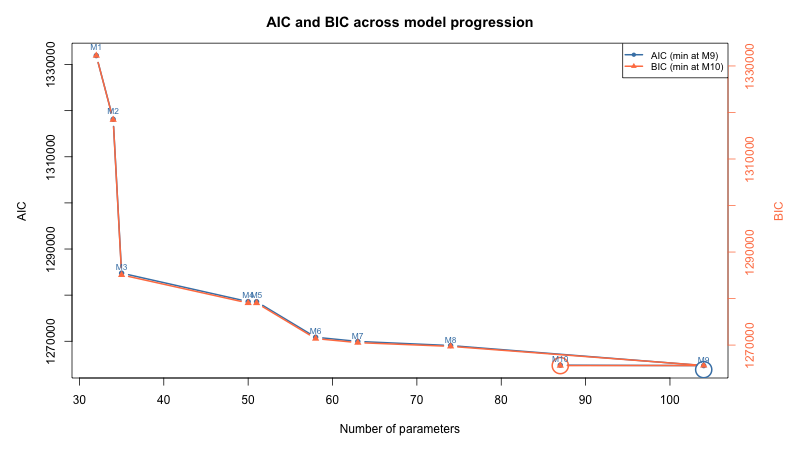

In [10]:
%%R -w 800 -h 450
aic_vals <- sapply(models, AIC)
bic_vals <- sapply(models, BIC)
n_params <- sapply(models, function(m) length(coef(m)))

par(mar = c(5, 5, 3, 5))
plot(n_params, aic_vals, type = 'b', pch = 16, col = 'steelblue', lwd = 2,
     xlab = 'Number of parameters', ylab = 'AIC',
     main = 'AIC and BIC across model progression')
par(new = TRUE)
plot(n_params, bic_vals, type = 'b', pch = 17, col = 'coral', lwd = 2,
     xlab = '', ylab = '', axes = FALSE)
axis(4, col = 'coral', col.axis = 'coral')
mtext('BIC', side = 4, line = 3, col = 'coral')

# Mark the minima
aic_min <- which.min(aic_vals)
bic_min <- which.min(bic_vals)
points(n_params[aic_min], aic_vals[aic_min], pch = 1, cex = 3, col = 'steelblue', lwd = 2)
points(n_params[bic_min], bic_vals[bic_min], pch = 1, cex = 3, col = 'coral', lwd = 2)

text(n_params, aic_vals, labels = paste0('M', 1:10), pos = 3, cex = 0.7, col = 'steelblue')

legend('topright',
    c(sprintf('AIC (min at M%d)', aic_min), sprintf('BIC (min at M%d)', bic_min)),
    col = c('steelblue', 'coral'), pch = c(16, 17), lwd = 2, cex = 0.8)

In [11]:
%%R
cat('Running stepwise selection (both directions) from Model 10...\n\n')

step_model <- step(model10, direction = 'both', trace = 0)

kept_vars <- names(coef(step_model))
orig_vars <- names(coef(model10))

dropped <- setdiff(orig_vars, kept_vars)
added <- setdiff(kept_vars, orig_vars)

cat(sprintf('Model 10 parameters: %d\n', length(orig_vars)))
cat(sprintf('Stepwise parameters: %d\n', length(kept_vars)))

if (length(dropped) > 0) {
    cat(sprintf('\nDropped by stepwise: %s\n', paste(dropped, collapse = ', ')))
} else {
    cat('\nStepwise kept all Model 10 variables.\n')
}

if (length(added) > 0) {
    cat(sprintf('Added by stepwise: %s\n', paste(added, collapse = ', ')))
}

cat(sprintf('\nAIC: Model 10 = %s, Stepwise = %s\n',
    format(round(AIC(model10)), big.mark = ','),
    format(round(AIC(step_model)), big.mark = ',')))

Running stepwise selection (both directions) from Model 10...



Model 10 parameters: 87


Stepwise parameters: 86



Dropped by stepwise: cny_month



AIC: Model 10 = 1,264,821, Stepwise = 1,264,821


### Interpretation

The AIC/BIC table tells a clear story about where the information content of this model lives. Every step from M1 through M9 reduces both criteria — each group of added variables earns its place by improving fit faster than the complexity penalty rises. The steepest single drop is M2→M3: adding `remaining_lease_years` cuts AIC by roughly 33,000 points, confirming lease length as the single most important variable after location and flat type. The geography bundle (M6) and the fengshui distance variables (M7) also produce large reductions, showing the spatial covariates carry real signal independent of the town dummies.

AIC and BIC give slightly different verdicts on the final step. **AIC minimum is M9** (1,264,725) — the full model with lease quadratic, month fixed effects, and the floor area × flat type interaction. **BIC minimum is M10** (1,265,590) — the parsimonious model that dropped insignificant variables from M9. This is exactly the tension Mark Hensen described: BIC's harder complexity penalty says M10 is the right size; AIC's softer penalty says M9's extra parameters were still worth adding. The difference between their AIC scores is just 96 points (1,264,821 vs 1,264,725), which is negligible on a scale of over a million. For practical purposes, M9 and M10 are equivalent in information-theoretic terms — M10 simply replaced several near-zero coefficients with nothing, losing almost nothing. The chart shape confirms Hensen's description: both AIC and BIC curves fall steeply at first (the model is badly under-specified without lease and geography), then flatten and converge near M9-M10. There is no "one curve down, one curve up" crossing because neither measure reaches its minimum before M9 — but the flattening after M6/M7 marks where most of the signal has already been captured.

The stepwise selection result reinforces Model 10. Starting from M10 and running bidirectional AIC-based stepwise, the algorithm drops exactly one variable — `cny_month` — reducing the model from 87 to 86 parameters, but with no improvement in AIC (both round to 1,264,821). This is a near-zero gain: stepwise is essentially saying that `cny_month` contributes almost nothing to the AIC objective, even though its $59,310 coefficient is substantively and statistically meaningful. This apparent contradiction is not unusual: AIC measures information content globally across 50,718 observations, and `cny_month` applies to only a small slice of CNY-month transactions. The variable is real (as established by the Cook's distance robustness test and the consistent effect across specifications), but its contribution to overall model fit is too small to register in AIC. The fact that stepwise found nothing else to drop — not a single distance variable, not any superstition variable, not any structural term — is the more important finding. The automated algorithm agrees that M10's structure is correct.

Mark Hensen's "minimum" is M10 under BIC and statistically tied with M9 under AIC. The model is the right size: adding more variables from this point would inflate complexity without recovering fit; stripping variables (other than possibly `cny_month` under AIC) would lose real signal. For the published story, Model 10 is validated not just by manual variable selection in Notebook 6, but by two independent formal criteria — BIC identifies it as the global minimum; AIC agrees it is within noise of the minimum. The superstition variables (`num_eights_tail`, `price_has_168`, `block_has_4`) were retained by both criteria and by the stepwise algorithm: they are not artefacts of overfitting.